# Chunk-Based BERT + Label Attention and focal loss

In [ ]:
# Initializes execution environment.

import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from src.config import (
    DATA_DIR, MODEL_C_DIR, TRANSFORMER_MODEL, MAX_SEQ_LEN, SEED,
    MODEL_C_MAX_CHUNKS, MODEL_C_CHUNK_STRIDE,
    MODEL_C_FROZEN_LR, MODEL_C_FINETUNE_LR,
    MODEL_C_FROZEN_EPOCHS, MODEL_C_FINETUNE_EPOCHS,
    MODEL_C_BATCH_SIZE, MODEL_C_GRAD_ACCUM, MODEL_C_DROPOUT,
    MODEL_C_FOCAL_GAMMA, MODEL_C_FOCAL_ALPHA, MODEL_C_EARLY_STOP,
    USE_AMP,
)
from src.train import set_seed

# Use a separate directory so v1 results are preserved
SAVE_DIR = MODEL_C_DIR / 'v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
    print(f'CUDA: {torch.version.cuda}')
    print(f'fp16: ENABLED')
else:
    print('WARNING: No GPU!')

print(f'\nv2 Config:')
print(f'  Focal loss:      gamma={MODEL_C_FOCAL_GAMMA}, alpha={MODEL_C_FOCAL_ALPHA}')
print(f'  Frozen epochs:   {MODEL_C_FROZEN_EPOCHS}')
print(f'  Finetune epochs: {MODEL_C_FINETUNE_EPOCHS} (early stop patience={MODEL_C_EARLY_STOP})')
print(f'  Batch:           {MODEL_C_BATCH_SIZE} x {MODEL_C_GRAD_ACCUM} = {MODEL_C_BATCH_SIZE * MODEL_C_GRAD_ACCUM}')

GPU: NVIDIA L4 (23.7 GB)
CUDA: 12.8
fp16: ENABLED

v2 Config:
  Focal loss:      gamma=2.0, alpha=0.25
  Frozen epochs:   5
  Finetune epochs: 7 (early stop patience=3)
  Batch:           4 x 8 = 32


## 1. Load Data

In [ ]:
# Loads the data splits and creates a label binarizer.

from src.data import load_splits, load_label_binarizer, build_label_matrix, get_icd_descriptions

train_df, val_df, test_df = load_splits()
mlb = load_label_binarizer()
vocab = list(mlb.classes_)
NUM_LABELS = len(vocab)

Y_train = build_label_matrix(train_df, mlb)
Y_val   = build_label_matrix(val_df, mlb)
Y_test  = build_label_matrix(test_df, mlb)

print(f'Labels: {NUM_LABELS}')
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00...
(warning truncated)


Labels: 50
Train: 85081  Val: 18371  Test: 18852


/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00...
(warning truncated)


## 2. Create Datasets & DataLoaders

In [ ]:
# Creates a dataset and data loader for the training, validation, and test sets.

from src.data import ChunkedICDDataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

train_ds = ChunkedICDDataset(train_df['clean_text'], Y_train, tokenizer=tokenizer)
val_ds   = ChunkedICDDataset(val_df['clean_text'],   Y_val,   tokenizer=tokenizer)
test_ds  = ChunkedICDDataset(test_df['clean_text'],  Y_test,  tokenizer=tokenizer)

train_loader = DataLoader(train_ds, batch_size=MODEL_C_BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=MODEL_C_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=MODEL_C_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

# Verify chunking
sample = train_ds[0]
print(f'Sample: input_ids={sample["input_ids"].shape}, chunks={sample["chunk_count"]}')

Train batches: 21271  Val: 4593  Test: 4713
Sample: input_ids=torch.Size([6, 512]), chunks=6


## 3. Building the Model

In [ ]:
# Initialize the Label Attention model.

from src.models import LabelAttentionClassifier

model = LabelAttentionClassifier(
    model_name=TRANSFORMER_MODEL,
    num_labels=NUM_LABELS,
    max_chunks=MODEL_C_MAX_CHUNKS,
    freeze_bert=True,
    dropout=MODEL_C_DROPOUT,
).to(device)

descriptions = get_icd_descriptions(vocab)
print('\nSample descriptions:')
for i in range(min(5, len(vocab))):
    print(f'  {vocab[i]:10s} -> {descriptions[i]}')

model.init_label_queries_from_descriptions(descriptions, tokenizer=tokenizer, device=device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters()) - trainable
print(f'\nTrainable: {trainable:,}  Frozen: {frozen:,}')
print(f'BERT: FROZEN (Phase 1)')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT...
(warning truncated)



Sample descriptions:
  02HV33Z    -> ICD-10 code 02HV33Z
  D62        -> ICD-10 code D62
  D649       -> Anemia unspecified
  D696       -> ICD-10 code D696
  E039       -> Hypothyroidism unspecified
Initialized label_queries from 50 code descriptions

Trainable: 76,850  Frozen: 108,310,272
BERT: FROZEN (Phase 1)


## 4. Phase 1: Frozen BERT with Focal Loss

In [ ]:
# Trains the model with frozen BERT.

from src.train import train_model

print('='*60)
print('PHASE 1: Frozen BERT + Focal Loss + Code Description Init')
print('='*60)

history_frozen = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=SAVE_DIR,
    lr=MODEL_C_FROZEN_LR,
    epochs=MODEL_C_FROZEN_EPOCHS,
    grad_accum=MODEL_C_GRAD_ACCUM,
    warmup_ratio=0.05,
    use_focal_loss=True,
    focal_gamma=MODEL_C_FOCAL_GAMMA,
    focal_alpha=MODEL_C_FOCAL_ALPHA,
    checkpoint_every=5000,
    is_chunked=True,
    device=device,
)

PHASE 1: Frozen BERT + Focal Loss + Code Description Init
  Using Focal Loss (gamma=2.0, alpha=0.25)
  Step 500/21271  loss=0.1111  GPU mem: 0.9GB
  Step 1000/21271  loss=0.0786  GPU mem: 0.9GB
  Step 1500/21271  loss=0.0628  GPU mem: 0.9GB
  Step 2000/21271  loss=0.0546  GPU mem: 0.9GB
  Step 2500/21271  loss=0.0495  GPU mem: 0.9GB
  Step 3000/21271  loss=0.0461  GPU mem: 0.9GB
  Step 3500/21271  loss=0.0436  GPU mem: 0.9GB
  Step 4000/21271  loss=0.0418  GPU mem: 0.9GB
  Step 4500/21271  loss=0.0404  GPU mem: 0.9GB
  Step 5000/21271  loss=0.0392  GPU mem: 0.9GB
  -> mid-epoch checkpoint saved
  Step 5500/21271  loss=0.0383  GPU mem: 0.9GB
  Step 6000/21271  loss=0.0375  GPU mem: 0.9GB
  Step 6500/21271  loss=0.0368  GPU mem: 0.9GB
  Step 7000/21271  loss=0.0362  GPU mem: 0.9GB
  Step 7500/21271  loss=0.0357  GPU mem: 0.9GB
  Step 8000/21271  loss=0.0352  GPU mem: 0.9GB
  Step 8500/21271  loss=0.0348  GPU mem: 0.9GB
  Step 9000/21271  loss=0.0344  GPU mem: 0.9GB
  Step 9500/21271  los

## 5. Phase 2: Fine-tune Last 2 BERT Layers with Early Stopping

In [ ]:
# Reloads the best Phase 1 checkpoint.

model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pt', map_location=device))
model.unfreeze_bert_layers(num_layers=2)

print('\n' + '='*60)
print('PHASE 2: Fine-tune + Focal Loss + Early Stopping')
print('='*60)

history_finetune = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=SAVE_DIR,
    lr=MODEL_C_FINETUNE_LR,
    epochs=MODEL_C_FINETUNE_EPOCHS,
    grad_accum=MODEL_C_GRAD_ACCUM,
    warmup_ratio=0.1,
    use_focal_loss=True,
    focal_gamma=MODEL_C_FOCAL_GAMMA,
    focal_alpha=MODEL_C_FOCAL_ALPHA,
    checkpoint_every=0,
    is_chunked=True,
    early_stopping_patience=MODEL_C_EARLY_STOP,
    device=device,
)

Unfroze last 2 BERT layers. Trainable params: 14,843,186

PHASE 2: Fine-tune + Focal Loss + Early Stopping
  Using Focal Loss (gamma=2.0, alpha=0.25)
  Step 500/21271  loss=0.0245  GPU mem: 1.1GB
  Step 1000/21271  loss=0.0244  GPU mem: 1.0GB
  Step 1500/21271  loss=0.0246  GPU mem: 1.1GB
  Step 2000/21271  loss=0.0246  GPU mem: 1.0GB
  Step 2500/21271  loss=0.0245  GPU mem: 1.1GB
  Step 3000/21271  loss=0.0245  GPU mem: 1.0GB
  Step 3500/21271  loss=0.0245  GPU mem: 1.1GB
  Step 4000/21271  loss=0.0244  GPU mem: 1.0GB
  Step 4500/21271  loss=0.0244  GPU mem: 1.1GB
  Step 5000/21271  loss=0.0244  GPU mem: 1.0GB
  Step 5500/21271  loss=0.0244  GPU mem: 1.1GB
  Step 6000/21271  loss=0.0244  GPU mem: 1.0GB
  Step 6500/21271  loss=0.0243  GPU mem: 1.1GB
  Step 7000/21271  loss=0.0243  GPU mem: 1.0GB
  Step 7500/21271  loss=0.0243  GPU mem: 1.1GB
  Step 8000/21271  loss=0.0242  GPU mem: 1.0GB
  Step 8500/21271  loss=0.0242  GPU mem: 1.1GB
  Step 9000/21271  loss=0.0242  GPU mem: 1.0GB
  Ste

## 6. Training History

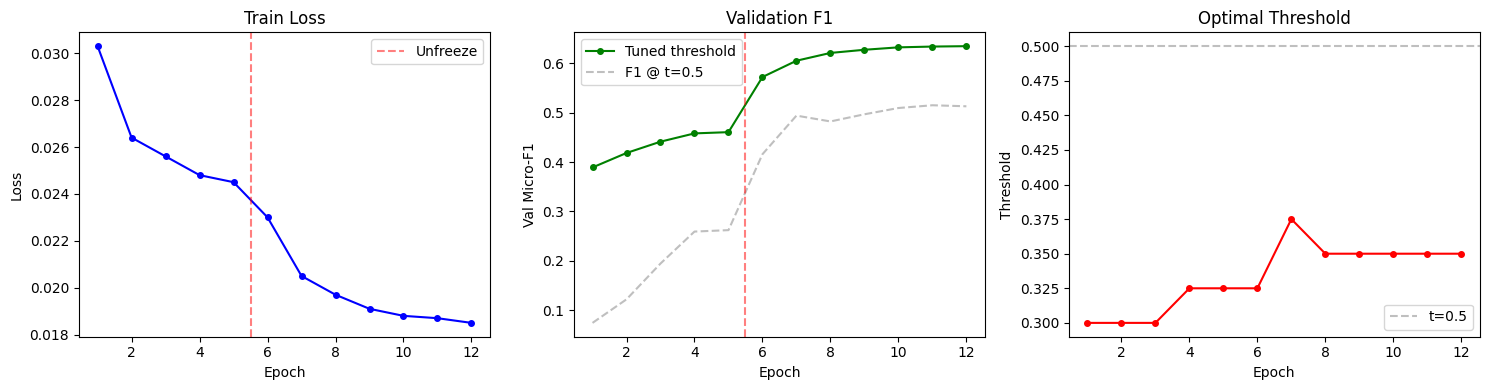

 epoch  train_loss  val_f1_at_0.5  val_f1_tuned  best_threshold
     1      0.0303         0.0743        0.3892           0.300
     2      0.0264         0.1220        0.4185           0.300
     3      0.0256         0.1945        0.4414           0.300
     4      0.0248         0.2593        0.4582           0.325
     5      0.0245         0.2622        0.4607           0.325
     6      0.0230         0.4160        0.5724           0.325
     7      0.0205         0.4942        0.6054           0.375
     8      0.0197         0.4824        0.6212           0.350
     9      0.0191         0.4969        0.6276           0.350
    10      0.0188         0.5096        0.6325           0.350
    11      0.0187         0.5152        0.6341           0.350
    12      0.0185         0.5131        0.6349           0.350


In [ ]:
# Plots the training history.

import matplotlib.pyplot as plt

full_history = history_frozen + [
    {**h, 'epoch': h['epoch'] + MODEL_C_FROZEN_EPOCHS} for h in history_finetune
]
hist_df = pd.DataFrame(full_history)
hist_df.to_csv(SAVE_DIR / 'full_training_history.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'b-o', markersize=4)
axes[0].axvline(x=MODEL_C_FROZEN_EPOCHS + 0.5, color='red', linestyle='--', alpha=0.5, label='Unfreeze')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Train Loss')
axes[0].legend()

# Val F1 (tuned vs default)
axes[1].plot(hist_df['epoch'], hist_df['val_f1_tuned'], 'g-o', markersize=4, label='Tuned threshold')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_at_0.5'], 'gray', linestyle='--', alpha=0.5, label='F1 @ t=0.5')
axes[1].axvline(x=MODEL_C_FROZEN_EPOCHS + 0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Micro-F1'); axes[1].set_title('Validation F1')
axes[1].legend()

# Threshold evolution
axes[2].plot(hist_df['epoch'], hist_df['best_threshold'], 'r-o', markersize=4)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='t=0.5')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Threshold'); axes[2].set_title('Optimal Threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves_v2.png', dpi=150)
plt.show()
print(hist_df.to_string(index=False))

## 7. Temperature Scaling (Calibration)

In [ ]:
# Fits a temperature scaler to the validation set.

from src.models import TemperatureScaler
from src.train import collect_logits, evaluate_predictions
from src.evaluate import tune_global_threshold, expected_calibration_error

model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pt', map_location=device))
model.eval()

print('Collecting validation logits...')
val_logits, val_labels = collect_logits(
    model, val_loader, device=device, use_amp=USE_AMP, is_chunked=True,
)

scaler = TemperatureScaler()
T = scaler.fit(val_logits, val_labels)

import torch as th
probs_uncal = th.sigmoid(th.tensor(val_logits)).numpy()
probs_cal   = scaler.calibrate(val_logits)

ece_before = expected_calibration_error(probs_uncal, val_labels)
ece_after  = expected_calibration_error(probs_cal, val_labels)

t_before, f1_before = tune_global_threshold(probs_uncal, val_labels)
t_after, f1_after   = tune_global_threshold(probs_cal, val_labels)

print(f'\nCalibration Results:')
print(f'  Before: ECE={ece_before:.4f}  best_t={t_before:.3f}  F1={f1_before:.4f}')
print(f'  After:  ECE={ece_after:.4f}  best_t={t_after:.3f}  F1={f1_after:.4f}')
print(f'  Temperature: {T:.4f}')

import json
with open(SAVE_DIR / 'temperature.json', 'w') as f:
    json.dump({'temperature': T, 'ece_before': ece_before, 'ece_after': ece_after}, f, indent=2)

Optimal temperature: 0.0427

Calibration Results:
  Before: ECE=0.1044  best_t=0.350  F1=0.6349
  After:  ECE=0.0672  best_t=0.050  F1=0.5586
  Temperature: 0.0427


## 8. Test Evaluation (with calibration + per-label thresholds)

In [ ]:
# Evaluates the model on the test set.

from src.evaluate import full_metrics, tune_per_label_threshold
import json

print('Computing test predictions...')
test_logits, Y_test_np = collect_logits(
    model, test_loader, device=device, use_amp=USE_AMP, is_chunked=True,
)

P_test_uncal = th.sigmoid(th.tensor(test_logits)).numpy()
P_test_cal = scaler.calibrate(test_logits)

best_t_global, _ = tune_global_threshold(probs_cal, val_labels)
results_global = full_metrics(P_test_cal, Y_test_np, best_t_global, 'Model C v2 (global threshold)')

per_label_t = tune_per_label_threshold(probs_cal, val_labels)
preds_per_label = np.zeros_like(P_test_cal, dtype=int)
for j in range(P_test_cal.shape[1]):
    preds_per_label[:, j] = (P_test_cal[:, j] >= per_label_t[j]).astype(int)

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
mask = Y_test_np.sum(0) > 0
results_per_label = {
    'Model':       'Model C v2 (per-label threshold)',
    'Threshold':   'per-label',
    'Micro-F1':    round(f1_score(Y_test_np, preds_per_label, average='micro', zero_division=0), 4),
    'Macro-F1':    round(f1_score(Y_test_np, preds_per_label, average='macro', zero_division=0), 4),
    'Micro-Prec':  round(precision_score(Y_test_np, preds_per_label, average='micro', zero_division=0), 4),
    'Micro-Rec':   round(recall_score(Y_test_np, preds_per_label, average='micro', zero_division=0), 4),
    'Macro-AUPRC': round(average_precision_score(Y_test_np[:, mask], P_test_cal[:, mask], average='macro'), 4),
    'Micro-AUROC': round(roc_auc_score(Y_test_np[:, mask], P_test_cal[:, mask], average='micro'), 4),
}

print('\n=== Test Results (Global Threshold) ===')
for k, v in results_global.items():
    print(f'  {k:15s}: {v}')

print('\n=== Test Results (Per-Label Thresholds) ===')
for k, v in results_per_label.items():
    print(f'  {k:15s}: {v}')

with open(SAVE_DIR / 'test_results.json', 'w') as f:
    json.dump({'global_threshold': results_global, 'per_label_threshold': results_per_label}, f, indent=2)
np.save(SAVE_DIR / 'P_test_calibrated.npy', P_test_cal)
np.save(SAVE_DIR / 'P_test_uncalibrated.npy', P_test_uncal)
np.save(SAVE_DIR / 'per_label_thresholds.npy', per_label_t)
print('\nResults saved to', SAVE_DIR)

Computing test predictions...

=== Test Results (Global Threshold) ===
  Model          : Model C v2 (global threshold)
  Threshold      : 0.05
  Micro-F1       : 0.5508
  Macro-F1       : 0.4309
  Micro-Prec     : 0.7895
  Micro-Rec      : 0.423
  Macro-AUPRC    : 0.5567
  Micro-AUROC    : 0.9185

=== Test Results (Per-Label Thresholds) ===
  Model          : Model C v2 (per-label threshold)
  Threshold      : per-label
  Micro-F1       : 0.5508
  Macro-F1       : 0.4309
  Micro-Prec     : 0.7896
  Micro-Rec      : 0.4229
  Macro-AUPRC    : 0.5567
  Micro-AUROC    : 0.9185

Results saved to /home/croha/ICD-CPT-Code-Prediction/data/models/model_c/v2


## 9. Head vs Tail Analysis

Bucket                          n   Avg F1
---------------------------------------------
head (>=500)                   50   0.4309
torso (100-499)                 0      nan
tail (<100)                     0      nan


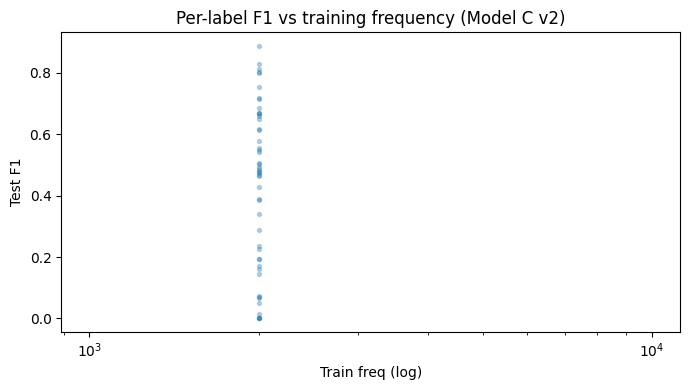

In [ ]:
# Analyzes the performance of the model across different label frequencies.

from sklearn.metrics import f1_score

per_label_f1 = f1_score(Y_test_np, preds_per_label, average=None, zero_division=0)
per_label_freq = Y_train.sum(0)

label_df = pd.DataFrame({
    'icd_code': vocab, 'train_freq': per_label_freq, 'test_f1': per_label_f1,
})

print(f'{"Bucket":25s}  {"n":>6}  {"Avg F1":>7}')
print('-' * 45)
for lo, hi, name in [(500, 1e9, 'head (>=500)'), (100, 499, 'torso (100-499)'), (0, 99, 'tail (<100)')]:
    s = label_df[(label_df['train_freq'] >= lo) & (label_df['train_freq'] <= hi)]
    print(f'{name:25s}  {len(s):6d}  {s["test_f1"].mean():7.4f}')

plt.figure(figsize=(7, 4))
plt.scatter(label_df['train_freq'].clip(upper=2000), label_df['test_f1'], alpha=0.3, s=8)
plt.xscale('log'); plt.xlabel('Train freq (log)'); plt.ylabel('Test F1')
plt.title('Per-label F1 vs training frequency (Model C v2)')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'head_tail_f1_v2.png', dpi=120)
plt.show()

## 10. Comparsion of chunk BERT v1 vs v2

In [ ]:
# Loads the results of Model A and Model B for comparison.

from src.config import MODEL_A_DIR, MODEL_B_DIR

with open(MODEL_A_DIR / 'results.json') as f:
    res_a = json.load(f)
with open(MODEL_B_DIR / 'test_results.json') as f:
    res_b = json.load(f)

v1_results = None
try:
    with open(MODEL_C_DIR / 'test_results.json') as f:
        v1_results = json.load(f)
except FileNotFoundError:
    print('v1 results not found')

comparison = pd.DataFrame([
    {'Model': 'A: TF-IDF + SGD',
     'Micro-F1': res_a['test']['micro_f1'],
     'Macro-F1': res_a['test']['macro_f1'],
     'AUROC': res_a['test']['micro_auroc']},
    {'Model': 'B: ClinicalBERT',
     'Micro-F1': res_b['micro_f1'],
     'Macro-F1': res_b['macro_f1'],
     'AUROC': res_b['micro_auroc']},
])

if v1_results:
    comparison = pd.concat([comparison, pd.DataFrame([{
        'Model': 'C v1: Chunk+Attn (buggy)',
        'Micro-F1': v1_results.get('Micro-F1', 0),
        'Macro-F1': v1_results.get('Macro-F1', 0),
        'AUROC': v1_results.get('Micro-AUROC', 0),
    }])], ignore_index=True)

comparison = pd.concat([comparison, pd.DataFrame([{
    'Model': 'C v2: Fixed (global t)',
    'Micro-F1': results_global['Micro-F1'],
    'Macro-F1': results_global['Macro-F1'],
    'AUROC': results_global['Micro-AUROC'],
}, {
    'Model': 'C v2: Fixed (per-label t)',
    'Micro-F1': results_per_label['Micro-F1'],
    'Macro-F1': results_per_label['Macro-F1'],
    'AUROC': results_per_label['Micro-AUROC'],
}])], ignore_index=True)

print('\n=== All Models Comparison ===')
print(comparison.to_string(index=False))
comparison.to_csv(SAVE_DIR / 'comparison_all.csv', index=False)


=== All Models Comparison ===
                    Model  Micro-F1  Macro-F1    AUROC
          A: TF-IDF + SGD  0.595187  0.569617 0.925018
          B: ClinicalBERT  0.524198  0.442893 0.868642
 C v1: Chunk+Attn (buggy)  0.530500  0.500000 0.893800
   C v2: Fixed (global t)  0.550800  0.430900 0.918500
C v2: Fixed (per-label t)  0.550800  0.430900 0.918500


## 11. Per Label Confusion Matrix

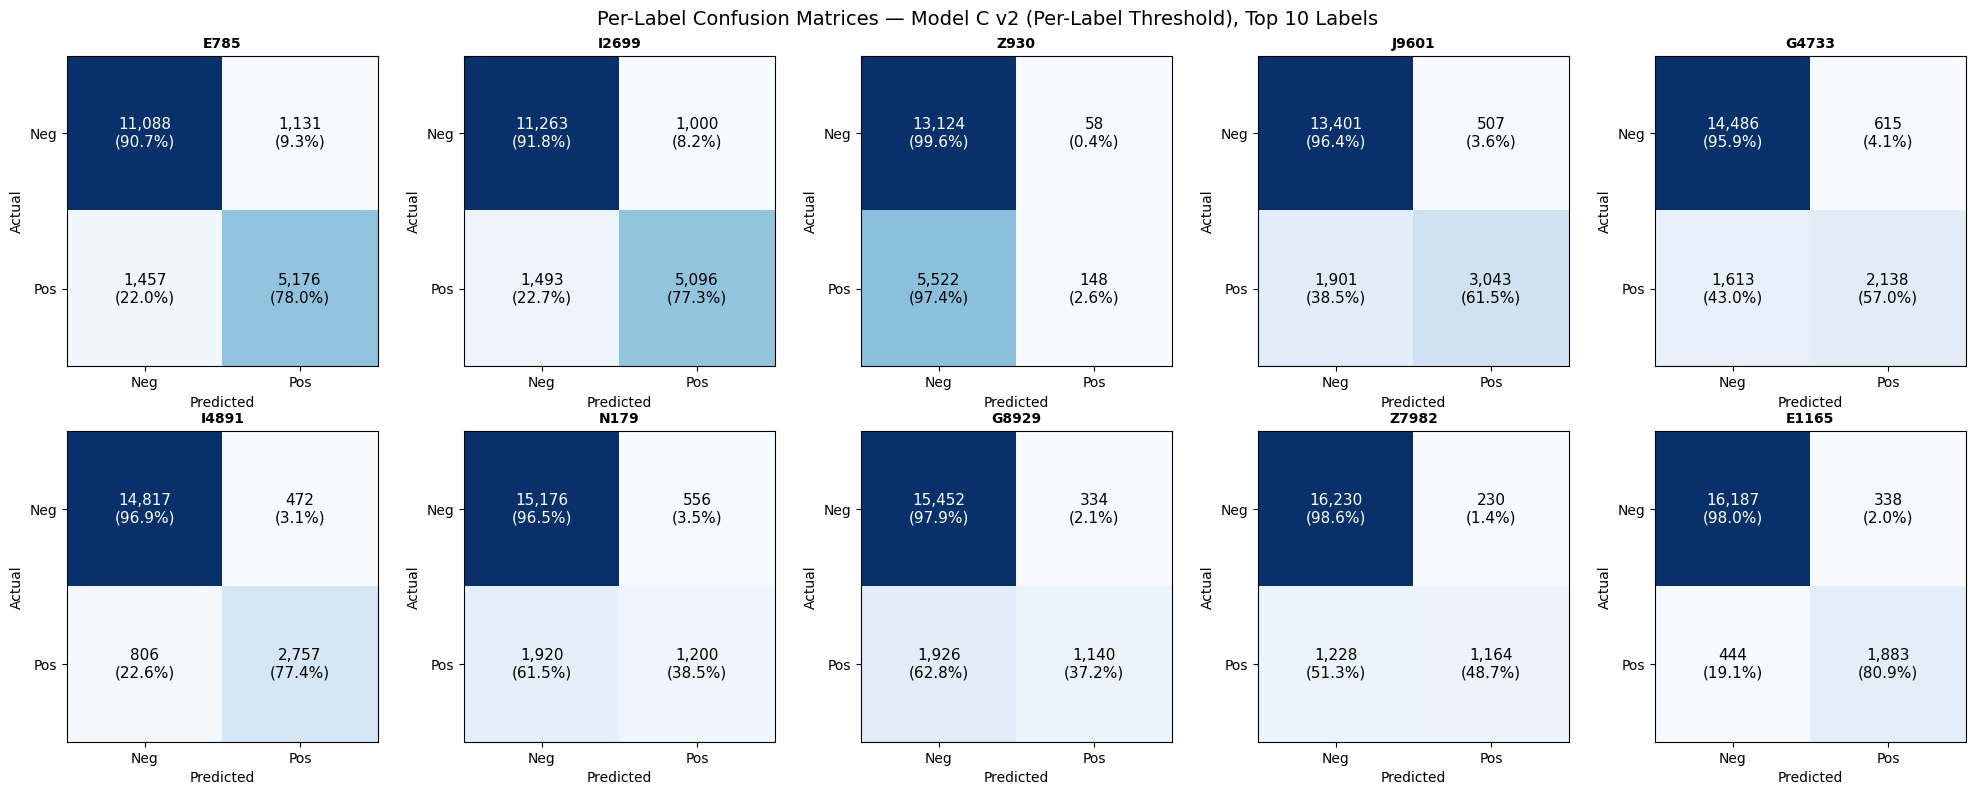


Aggregate Confusion Matrix (all 50 labels):
  TN =    834,550 (88.5%)   FP =     10,943 (1.2%)
  FN =     56,041 (5.9%)   TP =     41,066 (4.4%)


In [ ]:
# Plots the confusion matrix for each label.

import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import multilabel_confusion_matrix

DATA_DIR  = Path('../datasets/processed')
SAVE_DIR  = Path('../data/models/model_c/v2')
TOP_N = 10

with open(DATA_DIR / 'mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

Y_test  = np.load(DATA_DIR / 'Y_test.npy')

P_test = np.load(SAVE_DIR / 'P_test_calibrated.npy')

# per-label thresholds (tuned on validation set)
per_label_t = np.load(SAVE_DIR / 'per_label_thresholds.npy')
preds_test = (P_test >= per_label_t).astype(int)

mcm = multilabel_confusion_matrix(Y_test, preds_test)

freq = Y_test.sum(0)
top_idx = np.argsort(freq)[::-1][:TOP_N]

nrows, ncols = 2, TOP_N // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for idx, ax in zip(top_idx, axes.flat):
    cm = mcm[idx]
    ax.imshow(cm, cmap='Blues')
    ax.set_title(vocab[idx], fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
            row_total = cm[r].sum()
            pct = cm[r, c] / row_total * 100 if row_total > 0 else 0
            ax.text(c, r, f'{cm[r, c]:,}\n({pct:.1f}%)', ha='center', va='center', color=color, fontsize=11)

plt.suptitle(f'Per-Label Confusion Matrices — Model C v2 (Per-Label Threshold), Top {TOP_N} Labels', fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / f'confusion_matrix_top{TOP_N}.png', dpi=150)
plt.show()

agg = mcm.sum(axis=0)
print(f'\nAggregate Confusion Matrix (all {len(vocab)} labels):')
agg_total = agg.sum()
print(f'  TN = {agg[0,0]:>10,} ({agg[0,0]/agg_total*100:.1f}%)   FP = {agg[0,1]:>10,} ({agg[0,1]/agg_total*100:.1f}%)')
print(f'  FN = {agg[1,0]:>10,} ({agg[1,0]/agg_total*100:.1f}%)   TP = {agg[1,1]:>10,} ({agg[1,1]/agg_total*100:.1f}%)')

## 12. Full 50 Label Confusion Matrix and Analysis

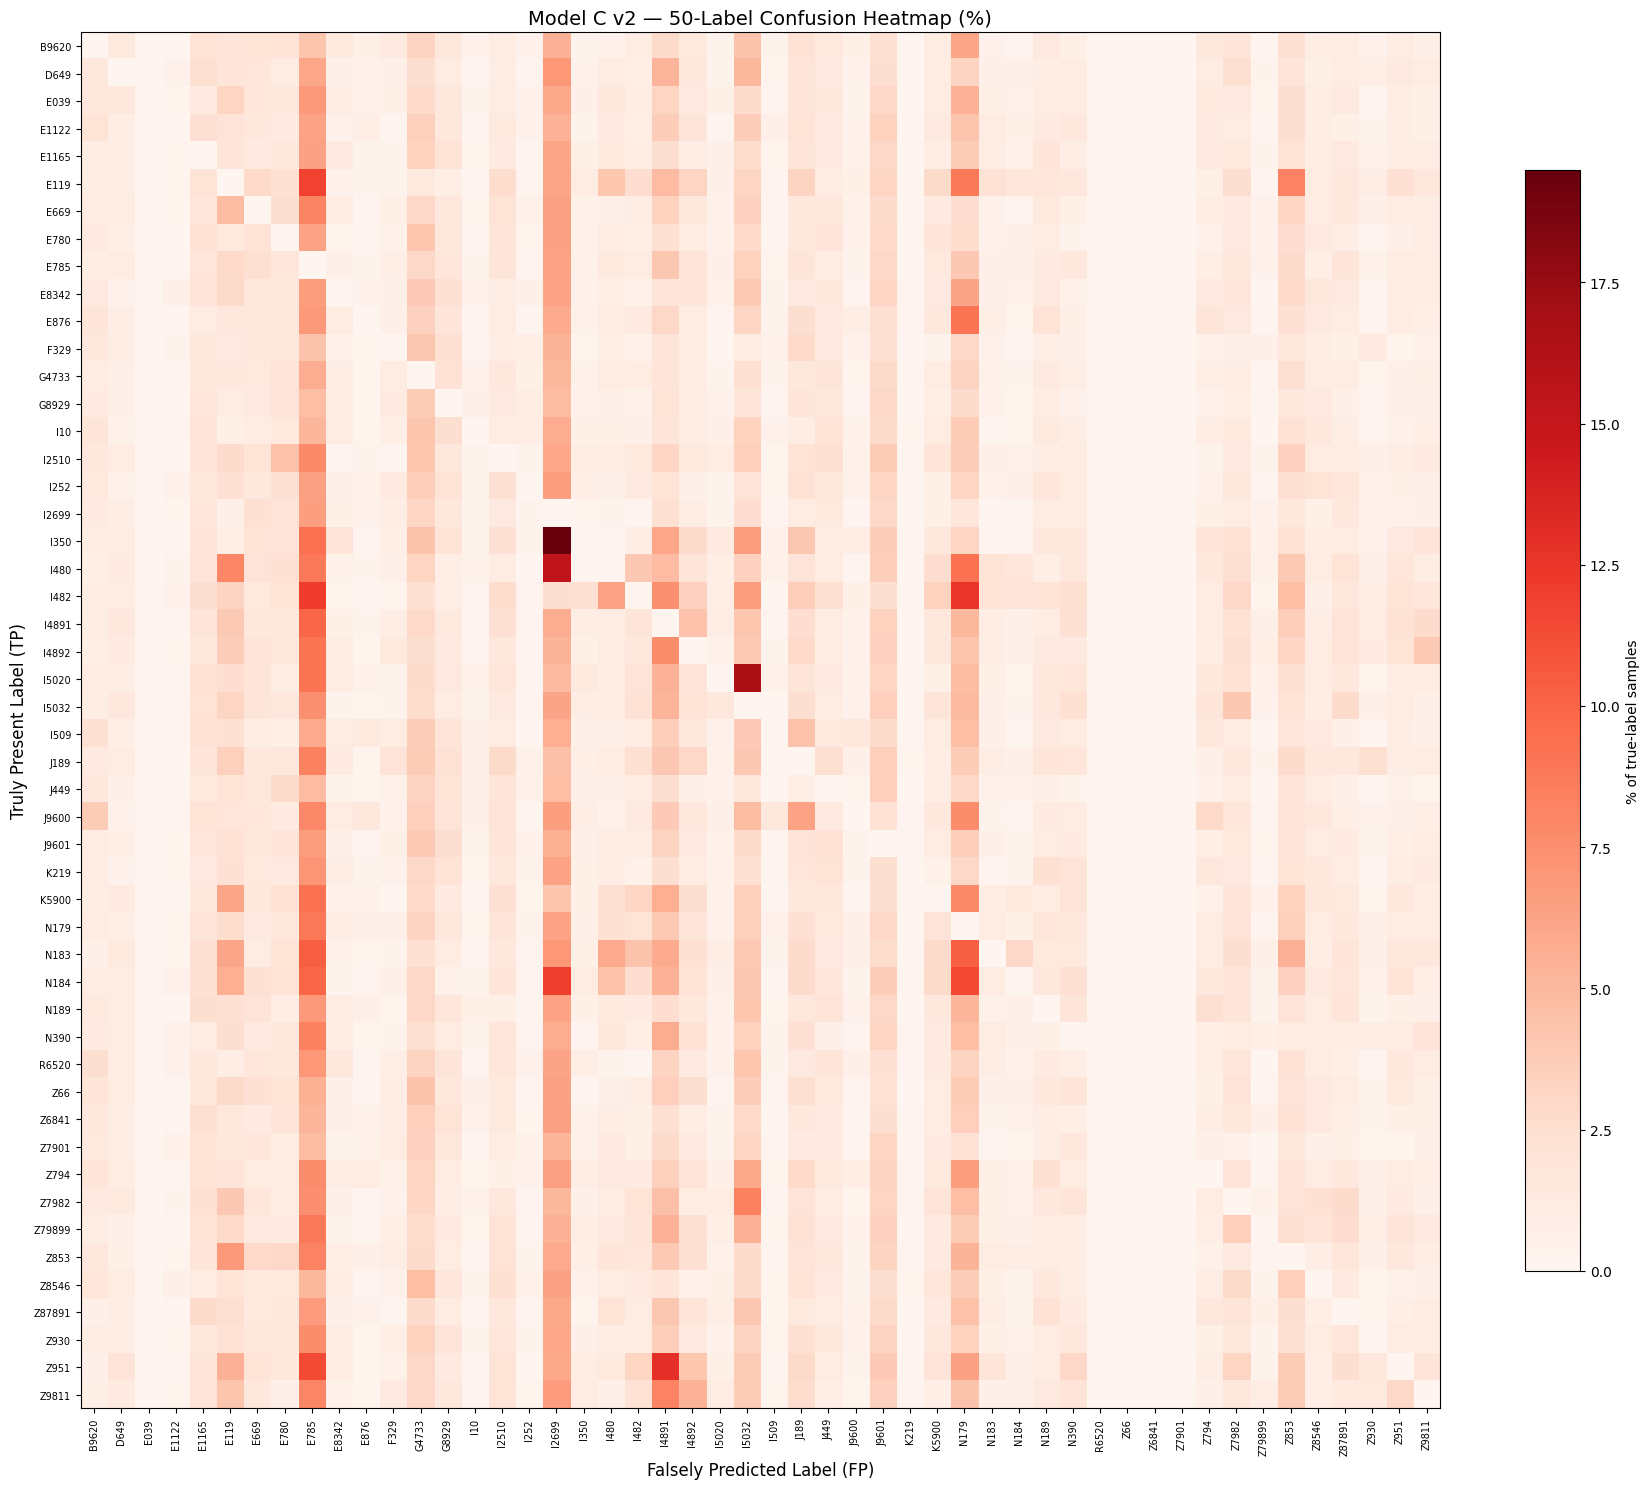


Top 20 most confused label pairs (Model C v2):
    True Label  →   Falsely Predicted    Count
  --------------------------------------------------
          Z930  →                E785      434  (7.7% of Z930 samples)
         I2699  →                E785      432  (6.6% of I2699 samples)
          E785  →               I2699      417  (6.3% of E785 samples)
         I4891  →                E785      352  (9.9% of I4891 samples)
          Z930  →               I2699      343  (6.0% of Z930 samples)
         J9601  →                E785      330  (6.7% of J9601 samples)
          N179  →                E785      277  (8.9% of N179 samples)
         J9601  →               I2699      272  (5.5% of J9601 samples)
          E785  →               I4891      270  (4.1% of E785 samples)
          E785  →                N179      264  (4.0% of E785 samples)
          I350  →               I2699      222  (19.5% of I350 samples)
          E785  →               I5032      221  (3.3% of E785 samp

In [ ]:
# Plots the confusion matrix for all 50 labels.

TOP_PAIRS = 20
n_labels = len(vocab)

fp_mask = (preds_test == 1) & (Y_test == 0)
tp_mask = (Y_test == 1)

label_confusion = tp_mask.astype(int).T @ fp_mask.astype(int)

fig, ax = plt.subplots(figsize=(18, 15))
row_sums = tp_mask.sum(axis=0).reshape(-1, 1)
row_sums = np.where(row_sums == 0, 1, row_sums)
label_confusion_pct = label_confusion / row_sums * 100
im = ax.imshow(label_confusion_pct, cmap='Reds', aspect='auto', interpolation='nearest')
ax.set_xticks(range(n_labels)); ax.set_yticks(range(n_labels))
ax.set_xticklabels(vocab, rotation=90, fontsize=7)
ax.set_yticklabels(vocab, fontsize=7)
ax.set_xlabel('Falsely Predicted Label (FP)', fontsize=12)
ax.set_ylabel('Truly Present Label (TP)', fontsize=12)
ax.set_title(f'Model C v2 — {n_labels}-Label Confusion Heatmap (%)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='% of true-label samples')
plt.tight_layout()
plt.savefig(SAVE_DIR / f'label_confusion_{n_labels}x{n_labels}.png', dpi=150)
plt.show()

np.fill_diagonal(label_confusion, 0)
flat_idx = np.argsort(label_confusion.ravel())[::-1]

print(f'\nTop {TOP_PAIRS} most confused label pairs (Model C v2):')
print(f'  {"True Label":>12s}  →  {"Falsely Predicted":>18s}  {"Count":>7s}')
print('  ' + '-' * 50)
shown = 0
for fi in flat_idx:
    if shown >= TOP_PAIRS:
        break
    i, j = divmod(fi, n_labels)
    count = label_confusion[i, j]
    if count == 0:
        break
    tp_total = tp_mask[:, i].sum()
    pct = count / tp_total * 100 if tp_total > 0 else 0
    print(f'  {vocab[i]:>12s}  →  {vocab[j]:>18s}  {count:>7,}  ({pct:.1f}% of {vocab[i]} samples)')
    shown += 1